Checkpoint 1: Imports and installations

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
appliances_energy_prediction = fetch_ucirepo(id=374) 
  
# data (as pandas dataframes) 
X = appliances_energy_prediction.data.features 
y = appliances_energy_prediction.data.targets 
  
# metadata 
appliances_energy_prediction.metadata
  
# variable information 
appliances_energy_prediction.variables


,name,role,type,demographic,description,units,missing_values
0,date,Feature,Date,None,None,NaN,no
1,Appliances,Target,Integer,None,None,Wh,no
2,lights,Feature,Integer,None,None,Wh,no
3,T1,Feature,Continuous,None,None,C,no
4,RH_1,Feature,Continuous,None,None,%,no
5,T2,Feature,Continuous,None,None,C,no
6,RH_2,Feature,Continuous,None,None,%,no
7,T3,Feature,Continuous,None,None,C,no
8,RH_3,Feature,Continuous,None,None,%,no
9,T4,Feature,Continuous,None,None,C,no


EDA

In [10]:
import pandas as pd

df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.dtypes)
df.head()


(19735, 29)
date               str
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
Appliances       int64
dtype: object


,date,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
0,2016-01-1117:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,60
1,2016-01-1117:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,60
2,2016-01-1117:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,50
3,2016-01-1117:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,50
4,2016-01-1117:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,60


Chechkpoint 3: Tipos correctos y calidad de datos

In [13]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d%H:%M:%S")
df = df.sort_values("date").reset_index(drop=True)

print(df["date"].min(), "->", df["date"].max())
print("nulos:", df.isna().sum().sum())
print("duplicados:", df.duplicated().sum())
print(df["date"].diff().value_counts().head())

2016-01-11 17:00:00 -> 2016-05-27 18:00:00
nulos: 0
duplicados: 0
date
0 days 00:10:00    19734
Name: count, dtype: int64


Checkpoint 4: El Target

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64
skew: 3.3863672147430623


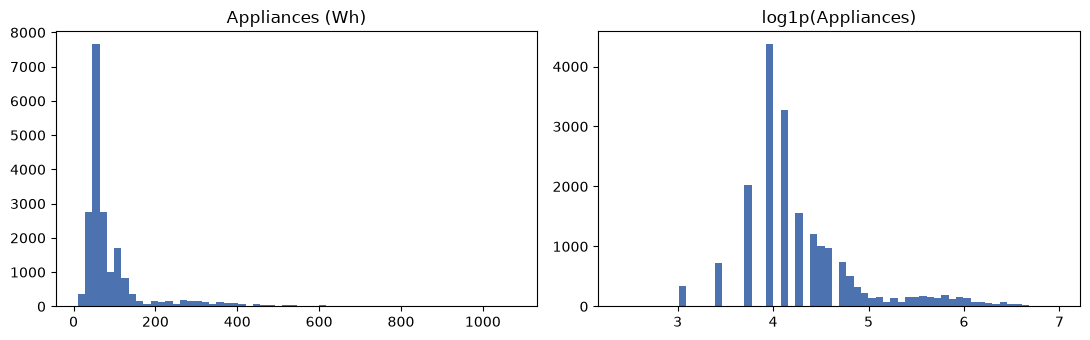

In [15]:
import numpy as np
import matplotlib.pyplot as plt

print(df["Appliances"].describe())
print("skew:", df["Appliances"].skew())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df["Appliances"], bins=60, color="#4C72B0")
axes[0].set_title("Appliances (Wh)")
axes[1].hist(np.log1p(df["Appliances"]), bins=60, color="#4C72B0")
axes[1].set_title("log1p(Appliances)")
plt.tight_layout()

Vamos a modelar log1p(Appliances)

Checkpoint 5: Los predictores: escala y variables sospechosas

In [16]:
features = df.drop(columns=["date", "Appliances"])

print(features.describe().T[["mean", "std", "min", "max"]])

print("\nrv1 == rv2:", (df["rv1"] == df["rv2"]).all())
print("\nlights:")
print(df["lights"].value_counts().sort_index())

                   mean        std         min         max
lights         3.801875   7.935988    0.000000   70.000000
T1            21.686571   1.606066   16.790000   26.260000
RH_1          40.259739   3.979299   27.023333   63.360000
T2            20.341219   2.192974   16.100000   29.856667
RH_2          40.420420   4.069813   20.463333   56.026667
T3            22.267611   2.006111   17.200000   29.236000
RH_3          39.242500   3.254576   28.766667   50.163333
T4            20.855335   2.042884   15.100000   26.200000
RH_4          39.026904   4.341321   27.660000   51.090000
T5            19.592106   1.844623   15.330000   25.795000
RH_5          50.949283   9.022034   29.815000   96.321667
T6             7.910939   6.090347   -6.065000   28.290000
RH_6          54.609083  31.149806    1.000000   99.900000
T7            20.267106   2.109993   15.390000   26.000000
RH_7          35.388200   5.114208   23.200000   51.400000
T8            22.029107   1.956162   16.306667   27.2300

1. Escalas totalmente distintas. Press_mm_hg con media 755 y lights con media 3.8. RH_6 con std 31 y T1 con std 1.6. Confirmado: hay que estandarizar antes de Ridge, Lasso y PCA. Sin eso, PCA te va a devolver una primera componente que es básicamente "presión atmosférica" solo porque tiene números grandes.

2. rv1 == rv2, idéntica. Columna duplicada, multicolinealidad perfecta. Decisión: eliminar rv2. Pero rv1 la DEJÁS, y te digo por qué: es ruido aleatorio puro, no tiene relación con el consumo. Si tu Lasso le pone coeficiente cero y tu Best Subset la deja afuera, tenés prueba de que la selección funciona. Es un canario en la mina.

3. lights es 77% ceros. No es una variable continua, es casi "¿hay luces prendidas o no?". Se queda, pero cuando veas su coeficiente interpretalo así.

Checkpoint 7: Correlaciones

lights         0.261143
T2             0.213784
T6             0.195821
T_out          0.175424
T3             0.166157
T1             0.159378
T8             0.152368
T4             0.131058
T7             0.109174
T5             0.108803
T9             0.091284
Windspeed      0.088046
RH_1           0.084757
Tdewpoint      0.055701
RH_5           0.024272
RH_3          -0.005733
RH_4          -0.006104
rv1           -0.010223
Visibility    -0.010854
Press_mm_hg   -0.072173
RH_2          -0.093405
RH_7          -0.095861
RH_9          -0.114999
RH_8          -0.164760
RH_6          -0.173072
RH_out        -0.225690
Name: log_appliances, dtype: float64


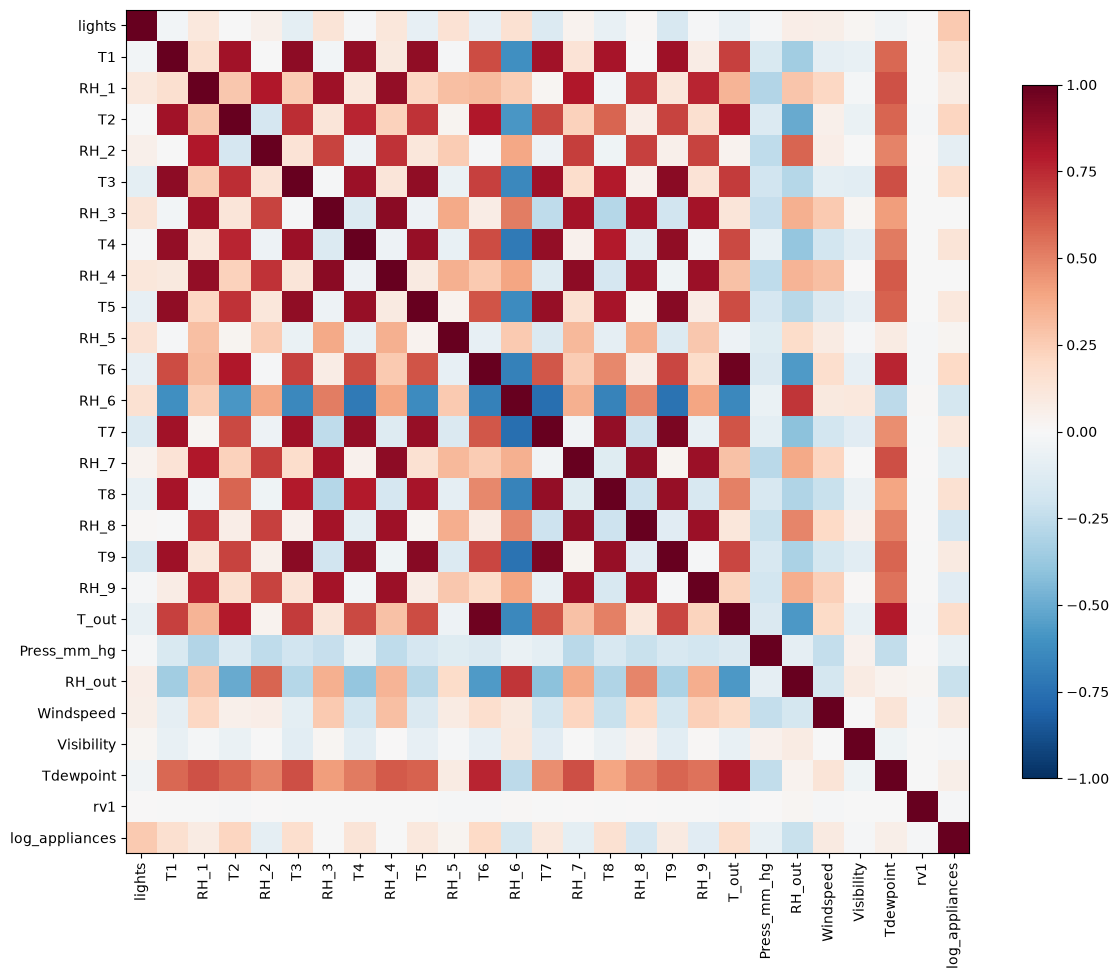

In [17]:
df = df.drop(columns=["rv2"])
df["log_appliances"] = np.log1p(df["Appliances"])

num = df.drop(columns=["date", "Appliances"])
corr = num.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

print(corr["log_appliances"].drop("log_appliances").sort_values(ascending=False))

Checkpoint 8: Cuantificar la multicolinealidad

In [18]:
pred_corr = num.drop(columns=["log_appliances"]).corr().abs()
upper = pred_corr.where(np.triu(np.ones(pred_corr.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
print(pairs[pairs > 0.9])

T6  T_out    0.974778
T7  T9       0.944776
T5  T9       0.911055
T3  T9       0.901324
dtype: float64


Cuatro pares por encima de 0.9, con T6/T_out casi idénticas.

Checkpoint 8:  El tiempo, que es donde vive la señal

hour              0.332743
hour_sin         -0.350402
hour_cos         -0.276257
is_weekend        0.042424
log_appliances    1.000000
Name: log_appliances, dtype: float64


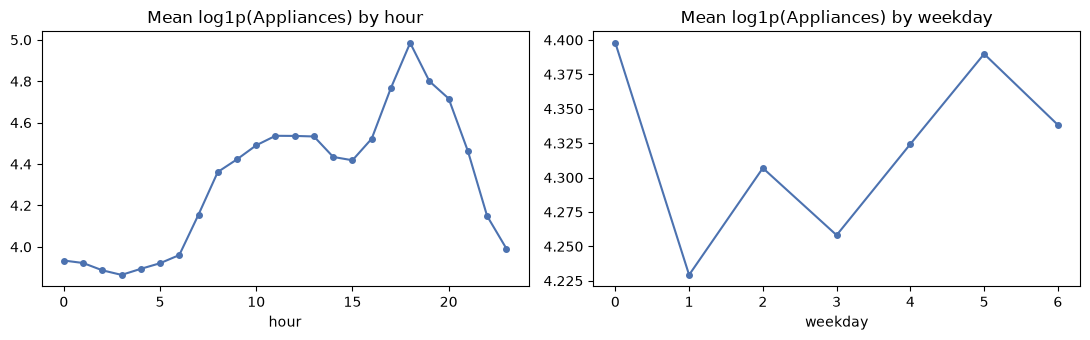

In [20]:
df["hour"] = df["date"].dt.hour
df["weekday"] = df["date"].dt.dayofweek  # 0 = Monday

# Cyclic encoding: hour 23 and hour 0 end up adjacent
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df.groupby("hour")["log_appliances"].mean().plot(ax=axes[0], color="#4C72B0", marker="o", ms=4)
axes[0].set_title("Mean log1p(Appliances) by hour")
df.groupby("weekday")["log_appliances"].mean().plot(ax=axes[1], color="#4C72B0", marker="o", ms=4)
axes[1].set_title("Mean log1p(Appliances) by weekday")
plt.tight_layout()

print(df[["hour", "hour_sin", "hour_cos", "is_weekend", "log_appliances"]].corr()["log_appliances"])


Checkpoint 9: Cierre del EDA: matriz de features y split temporal

In [26]:
from sklearn.preprocessing import StandardScaler

drop_cols = ["date", "Appliances", "log_appliances", "hour", "weekday"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_all = df[feature_cols]
y_all = df["log_appliances"]

# Temporal split: first 80% of the timeline trains, last 20% tests
split_idx = int(len(df) * 0.8)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

# Fit the scaler on train only, then apply to both
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("features:", len(feature_cols))
print("train:", X_train_s.shape, df["date"].iloc[0].date(), "->", df["date"].iloc[split_idx - 1].date())
print("test: ", X_test_s.shape, df["date"].iloc[split_idx].date(), "->", df["date"].iloc[-1].date())
print(X_train_s.describe().T[["mean", "std"]].round(2).head())

features: 29
train: (15788, 29) 2016-01-11 -> 2016-04-30
test:  (3947, 29) 2016-04-30 -> 2016-05-27
        mean  std
lights   0.0  1.0
T1      -0.0  1.0
RH_1     0.0  1.0
T2       0.0  1.0
RH_2    -0.0  1.0


Resumen EDA:

1. Dataset limpio: sin nulos, sin duplicados, serie continua de 10 minutos durante 4.5 meses. La fecha venía mal formateada y se parseó con formato explícito.
2. Target con skew 3.39 y cola larga a la derecha, discretizado en saltos de 10 Wh. Decisión: modelar log1p(Appliances).
3. rv2 idéntica a rv1: eliminada. rv1 se conserva como control de ruido para validar la selección de variables.
4. Escalas muy heterogéneas entre predictores. Decisión: estandarizar, ajustando el scaler solo con train.
5. Fuerte multicolinealidad: bloques de temperaturas y humedades correlacionados entre sí, cuatro pares por encima de 0.9. Se conservan todos a propósito para comparar cómo los trata cada método.
6. Correlación lineal débil con el target: ningún sensor supera 0.26. La hora del día, codificada cíclicamente, es el predictor más fuerte. Se agregan hour_sin, hour_cos e is_weekend.
7. Split temporal 80/20, sin shuffle, para evitar fuga de información entre filas vecinas.

Checkpoint M1 — Baseline: regresión lineal con TODAS las features

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    return {
        "model": name,
        "n_features": X_tr.shape[1],
        "r2_train": r2_score(y_tr, pred_tr),
        "r2_test": r2_score(y_te, pred_te),
        "rmse_test": np.sqrt(mean_squared_error(y_te, pred_te)),
    }

results = []
results.append(evaluate(LinearRegression(), X_train_s, y_train, X_test_s, y_test, "OLS all features"))
pd.DataFrame(results)

,model,n_features,r2_train,r2_test,rmse_test
0,OLS all features,29,0.346468,0.229336,0.490546


Checkpoint M2 — Best Subset Selection

In [33]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

efs = EFS(LinearRegression(), min_features=1, max_features=4, scoring="r2",
          cv=tscv, n_jobs=-1, print_progress=False).fit(X_train_s, y_train)

# Best subset for each size k, chosen by temporal CV score only
efs_df = pd.DataFrame.from_dict(efs.subsets_, orient="index")
efs_df["n_features"] = efs_df["feature_idx"].apply(len)
best_per_k = efs_df.loc[efs_df.groupby("n_features")["avg_score"].idxmax()].copy()
best_per_k["r2_test"] = [
    evaluate(LinearRegression(), X_train_s[list(f)], y_train, X_test_s[list(f)], y_test, "")["r2_test"]
    for f in best_per_k["feature_names"]
]

print("best overall by CV:", efs.best_feature_names_, round(efs.best_score_, 3))
print(best_per_k[["n_features", "feature_names", "avg_score", "r2_test"]].round(3).to_string())

best overall by CV: ('T3', 'T6', 'hour_sin', 'hour_cos') 0.257
       n_features                 feature_names  avg_score  r2_test
26              1                   (hour_sin,)      0.111    0.067
432             2          (hour_sin, hour_cos)      0.194    0.179
2315            3      (T3, hour_sin, hour_cos)      0.244    0.039
18302           4  (T3, T6, hour_sin, hour_cos)      0.257    0.147


In [34]:
import statsmodels.api as sm

cols = best_subsets[4]
ols = sm.OLS(y_train, sm.add_constant(X_train_s[cols])).fit()
print(ols.summary().tables[1])
print("AIC:", ols.aic, "BIC:", ols.bic)

print("\nT3 in train vs test:")
print(pd.DataFrame({"train": X_train["T3"].describe(), "test": X_test["T3"].describe()}).round(2))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3073      0.004    957.823      0.000       4.298       4.316
lights         0.1569      0.005     33.931      0.000       0.148       0.166
T3             0.1312      0.005     28.991      0.000       0.122       0.140
hour_sin      -0.1940      0.005    -41.822      0.000      -0.203      -0.185
hour_cos      -0.1878      0.005    -41.697      0.000      -0.197      -0.179
AIC: 26784.18410808933 BIC: 26822.519135273244

T3 in train vs test:
          train     test
count  15788.00  3947.00
mean      21.59    24.98
std        1.50     1.39
min       17.20    22.10
25%       20.50    24.10
50%       21.63    24.86
75%       22.60    26.17
max       27.60    29.24


- T3 tiene t = 29 y p-value 0.000. En train es una de las variables más significativas del modelo. Statsmodels te diría "quedátela".
- Pero el percentil 25 de T3 en test (24.1) está por ENCIMA del percentil 75 en train (22.6). Tres cuartos de los datos de mayo viven en una zona que en train era la cola caliente.

El modelo aprendió "más temperatura, más consumo" con datos de invierno, y en mayo esa relación se rompe. Significancia estadística no es capacidad de generalizar. Ese párrafo, con esta tabla al lado, es lo mejor que va a tener tu informe.

Nota al margen: el BIC de statsmodels (26822) no coincide con el tuyo (-17981) porque usan constantes distintas en la fórmula. No es un error, y las diferencias ENTRE modelos sí coinciden, que es lo único que importa para comparar.

Checkpoint M3 — Forward Stepwise Selection

In [31]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

sfs_fwd = SFS(LinearRegression(), k_features=(1, len(feature_cols)), forward=True,
              floating=False, scoring="r2", cv=tscv, n_jobs=-1).fit(X_train_s, y_train)

fwd_df = pd.DataFrame.from_dict(sfs_fwd.get_metric_dict(), orient="index")
fwd_df["n_features"] = fwd_df.index
fwd_df["r2_test"] = [
    evaluate(LinearRegression(), X_train_s[list(f)], y_train, X_test_s[list(f)], y_test, "")["r2_test"]
    for f in fwd_df["feature_names"]
]

print("best k by CV:", len(sfs_fwd.k_feature_names_), sfs_fwd.k_feature_names_)
print(fwd_df[["n_features", "avg_score", "r2_test"]].round(3).to_string())
print("\nrv1 enters at k =", next(k for k, f in sfs_fwd.subsets_.items() if "rv1" in f["feature_names"]))

best k by CV: 8 ('RH_1', 'T3', 'T5', 'T6', 'RH_9', 'Windspeed', 'hour_sin', 'hour_cos')
    n_features  avg_score  r2_test
1            1      0.111    0.067
2            2      0.194    0.179
3            3      0.244    0.039
4            4      0.257    0.147
5            5      0.269    0.118
6            6      0.273    0.125
7            7      0.273    0.147
8            8      0.274    0.161
9            9      0.273    0.161
10          10      0.273    0.164
11          11      0.271    0.163
12          12      0.270    0.167
13          13      0.269    0.168
14          14      0.267    0.169
15          15      0.265    0.186
16          16      0.259    0.180
17          17      0.251    0.166
18          18      0.268    0.239
19          19      0.272    0.234
20          20      0.269    0.213
21          21      0.257    0.212
22          22      0.244    0.207
23          23      0.216    0.222
24          24      0.233    0.224
25          25      0.220    0.229
26

In [35]:
print(set(sfs_fwd.subsets_[18]["feature_names"]) - set(sfs_fwd.subsets_[17]["feature_names"]))

{'T9'}


Checkpoint M4 — Backward Stepwise

In [36]:
sfs_bwd = SFS(LinearRegression(), k_features=(1, len(feature_cols)), forward=False,
              floating=False, scoring="r2", cv=tscv, n_jobs=-1).fit(X_train_s, y_train)

bwd_df = pd.DataFrame.from_dict(sfs_bwd.get_metric_dict(), orient="index")
bwd_df["n_features"] = bwd_df.index
bwd_df["r2_test"] = [
    evaluate(LinearRegression(), X_train_s[list(f)], y_train, X_test_s[list(f)], y_test, "")["r2_test"]
    for f in bwd_df["feature_names"]
]

print("best k by CV:", len(sfs_bwd.k_feature_names_), sfs_bwd.k_feature_names_)
print("same set as forward:", set(sfs_bwd.k_feature_names_) == set(sfs_fwd.k_feature_names_))
print("rv1 removed at k =", max(k for k, f in sfs_bwd.subsets_.items() if "rv1" in f["feature_names"]))
print(bwd_df[["n_features", "avg_score", "r2_test"]].round(3).to_string())

best k by CV: 13 ('RH_1', 'T3', 'RH_3', 'RH_4', 'RH_6', 'T8', 'RH_8', 'T9', 'RH_9', 'RH_out', 'hour_sin', 'hour_cos', 'is_weekend')
same set as forward: False
rv1 removed at k = 29
    n_features  avg_score  r2_test
29          29      0.173    0.229
28          28      0.203    0.226
27          27      0.214    0.202
26          26      0.227    0.197
25          25      0.237    0.199
24          24      0.246    0.199
23          23      0.255    0.209
22          22      0.259    0.209
21          21      0.264    0.209
20          20      0.265    0.209
19          19      0.266    0.208
18          18      0.267    0.208
17          17      0.268    0.208
16          16      0.267    0.206
15          15      0.267    0.206
14          14      0.266    0.173
13          13      0.281    0.172
12          12      0.278    0.168
11          11      0.275    0.158
10          10      0.270    0.165
9            9      0.264    0.180
8            8      0.277    0.178
7            7

Tres lecturas, y cerramos la selección de variables.

1. El canario, de nuevo. "rv1 removed at k = 29" significa que rv1 solo está en el conjunto completo: fue LA PRIMERA variable que Backward eliminó. Forward la agregó última útil, Backward la sacó primera. Dos algoritmos independientes coinciden en que es ruido. Prueba cerrada.

2. Forward y Backward NO llegan al mismo lugar. Forward eligió 8 features, Backward 13, y los conjuntos son distintos. Ambos son codiciosos: uno va agregando, otro sacando, y con 29 variables correlacionadas hay muchos caminos que dan casi el mismo R² de CV (0.27 contra 0.28). Cuando los predictores son intercambiables, la selección no es única. Ese es un argumento en contra de interpretar demasiado "las variables elegidas".

3. Ninguno le gana al baseline. Forward k=8: 0.16 en test. Backward k=13: 0.17. Las 29 features: 0.23. Cuatro métodos de selección, y todos pierden contra no seleccionar nada. Lo repito porque es la conclusión del bloque: con cambio de estación, los modelos ralos son frágiles y los sensores redundantes amortiguan.

Checkpoint M5 — Ridge

best alpha: 1215.4742500762884
              model  n_features  r2_train  r2_test
0  OLS all features          29     0.346    0.229
1   Best subset k=1           1     0.130    0.067
2   Best subset k=2           2     0.200    0.179
3   Best subset k=3           3     0.248    0.163
4   Best subset k=4           4     0.286    0.081
5  Ridge (CV alpha)          29     0.332    0.242


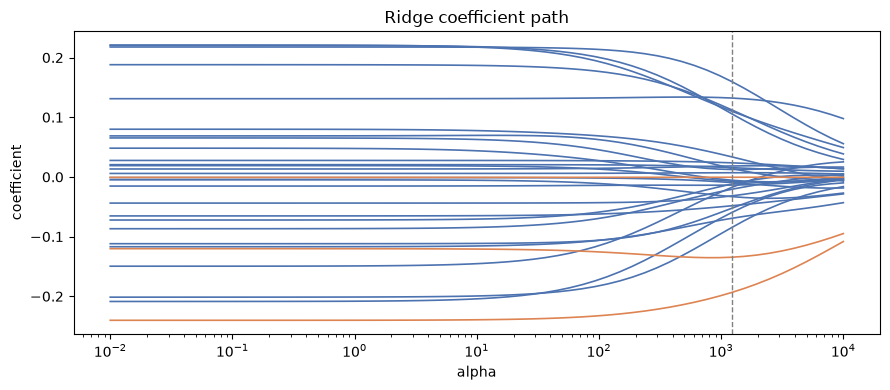

In [38]:
from sklearn.linear_model import Ridge, RidgeCV

alphas = np.logspace(-2, 4, 60)
ridge_cv = RidgeCV(alphas=alphas, cv=tscv).fit(X_train_s, y_train)
print("best alpha:", ridge_cv.alpha_)

results.append(evaluate(Ridge(alpha=ridge_cv.alpha_), X_train_s, y_train, X_test_s, y_test, "Ridge (CV alpha)"))
print(pd.DataFrame(results)[["model", "n_features", "r2_train", "r2_test"]].round(3).to_string())

# Coefficient path: how each coefficient shrinks as alpha grows
coefs = np.array([Ridge(alpha=a).fit(X_train_s, y_train).coef_ for a in alphas])
fig, ax = plt.subplots(figsize=(9, 4))
for j, c in enumerate(feature_cols):
    ax.plot(alphas, coefs[:, j], lw=1.2, color="#4C72B0" if c not in ("hour_sin", "hour_cos", "rv1") else "#DD8452")
ax.axvline(ridge_cv.alpha_, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_ylabel("coefficient"); ax.set_title("Ridge coefficient path")
plt.tight_layout()

Checkpoint M6 — Lasso

best alpha: 0.01200152309479056
non-zero: 17 / 29
rv1 coef: -0.0
hour_cos      -0.200
hour_sin      -0.161
T3             0.141
lights         0.135
T8             0.086
T9            -0.072
RH_1           0.038
RH_3           0.034
RH_9          -0.031
T6            -0.030
RH_7          -0.022
RH_8          -0.020
T4            -0.011
RH_5           0.010
is_weekend     0.008
Press_mm_hg   -0.006
T_out         -0.002
              model  n_features  r2_train  r2_test
0  OLS all features          29     0.346    0.229
1   Best subset k=1           1     0.130    0.067
2   Best subset k=2           2     0.200    0.179
3   Best subset k=3           3     0.248    0.163
4   Best subset k=4           4     0.286    0.081
5  Ridge (CV alpha)          29     0.332    0.242
6  Lasso (CV alpha)          29     0.315    0.213


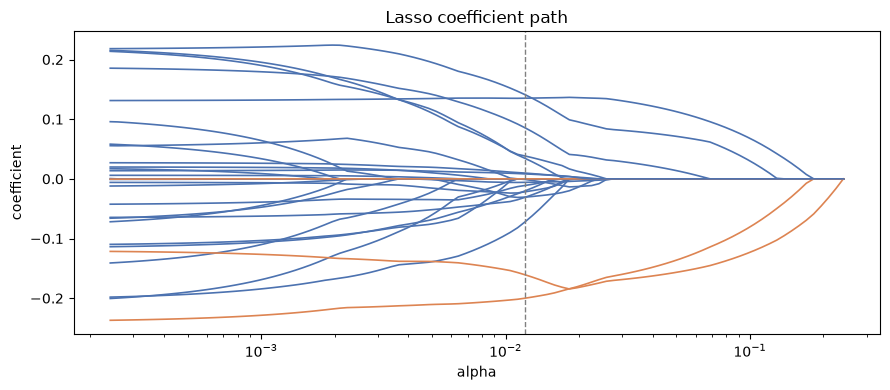

In [40]:
from sklearn.linear_model import Lasso, LassoCV, lasso_path

lasso_cv = LassoCV(cv=tscv, alphas=100, max_iter=20000, random_state=0).fit(X_train_s, y_train)
lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=20000).fit(X_train_s, y_train)
print("best alpha:", lasso_cv.alpha_)

kept = pd.Series(lasso.coef_, index=feature_cols)
print("non-zero:", (kept != 0).sum(), "/ 29")
print("rv1 coef:", kept["rv1"])
print(kept[kept != 0].sort_values(key=abs, ascending=False).round(3).to_string())

results.append(evaluate(Lasso(alpha=lasso_cv.alpha_, max_iter=20000), X_train_s, y_train, X_test_s, y_test, "Lasso (CV alpha)"))
print(pd.DataFrame(results)[["model", "n_features", "r2_train", "r2_test"]].round(3).to_string())

alphas_l, coefs_l, _ = lasso_path(X_train_s.values, y_train.values, alphas=100)
fig, ax = plt.subplots(figsize=(9, 4))
for j, c in enumerate(feature_cols):
    ax.plot(alphas_l, coefs_l[j], lw=1.2, color="#4C72B0" if c not in ("hour_sin", "hour_cos", "rv1") else "#DD8452")
ax.axvline(lasso_cv.alpha_, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_ylabel("coefficient"); ax.set_title("Lasso coefficient path")
plt.tight_layout()

Checkpoint M7 — PCA y regresión sobre componentes

components for 80/90/95% variance: [8, 12, 15]
best M by CV: 17
 param_pca__n_components  mean_test_score
                       1           -0.034
                       2            0.015
                       3            0.022
                       4            0.106
                       5            0.120
                       6            0.116
                       7            0.122
                       8            0.128
                       9            0.148
                      10            0.148
                      11            0.148
                      12            0.182
                      13            0.174
                      14            0.179
                      15            0.201
                      16            0.211
                      17            0.212
                      18            0.196
                      19            0.183
                      20            0.180
                      21            0.172
            

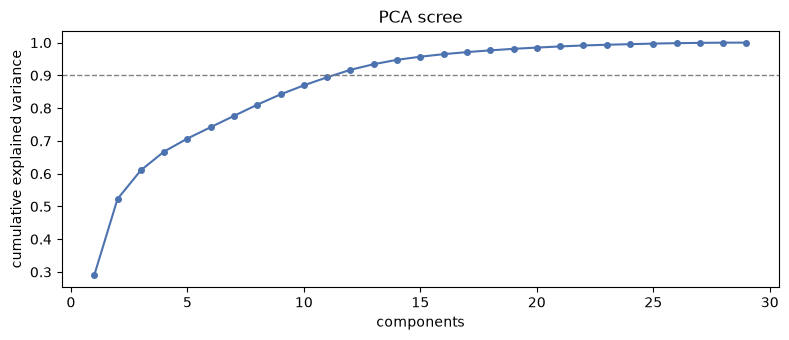

In [42]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pca = PCA().fit(X_train_s)
cum_var = np.cumsum(pca.explained_variance_ratio_)
print("components for 80/90/95% variance:", [int(np.argmax(cum_var >= t)) + 1 for t in (0.8, 0.9, 0.95)])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, 30), cum_var, marker="o", ms=4, color="#4C72B0")
ax.axhline(0.9, color="gray", ls="--", lw=1)
ax.set_xlabel("components"); ax.set_ylabel("cumulative explained variance"); ax.set_title("PCA scree")
plt.tight_layout()

pcr = Pipeline([("pca", PCA()), ("ols", LinearRegression())])
grid = GridSearchCV(pcr, {"pca__n_components": range(1, 30)}, cv=tscv, scoring="r2").fit(X_train_s, y_train)
best_m = grid.best_params_["pca__n_components"]
print("best M by CV:", best_m)

cv_curve = pd.DataFrame(grid.cv_results_)[["param_pca__n_components", "mean_test_score"]]
print(cv_curve.round(3).to_string(index=False))

results.append(evaluate(Pipeline([("pca", PCA(n_components=best_m)), ("ols", LinearRegression())]),
                        X_train_s, y_train, X_test_s, y_test, f"PCR (M={best_m})"))
print(pd.DataFrame(results)[["model", "n_features", "r2_train", "r2_test"]].round(3).to_string())


In [43]:
print(pd.DataFrame(pca.components_[:12], columns=feature_cols).T.loc[["hour_sin", "hour_cos"]].round(2))

            0     1     2     3     4     5     6     7     8     9     10  \
hour_sin  0.11 -0.04  0.27  0.49 -0.05 -0.04  0.02 -0.13 -0.14 -0.39 -0.11   
hour_cos  0.02  0.00  0.37 -0.25  0.11  0.02 -0.18  0.26 -0.16  0.56 -0.01   

            11  
hour_sin  0.31  
hour_cos  0.41  


In [44]:
for name, sfs in [("Forward stepwise", sfs_fwd), ("Backward stepwise", sfs_bwd)]:
    cols = list(sfs.k_feature_names_)
    results.append(evaluate(LinearRegression(), X_train_s[cols], y_train, X_test_s[cols], y_test, f"{name} (k={len(cols)})"))

final = pd.DataFrame(results).drop_duplicates("model").sort_values("r2_test", ascending=False)
final.loc[final["model"].str.startswith("Lasso"), "n_features"] = int((lasso.coef_ != 0).sum())
final.loc[final["model"].str.startswith("PCR"), "n_features"] = best_m
print(final[["model", "n_features", "r2_train", "r2_test", "rmse_test"]].round(3).to_string(index=False))

                   model  n_features  r2_train  r2_test  rmse_test
        Ridge (CV alpha)          29     0.332    0.242      0.487
        OLS all features          29     0.346    0.229      0.491
              PCR (M=17)          17     0.310    0.227      0.491
        Lasso (CV alpha)          17     0.315    0.213      0.496
         Best subset k=2           2     0.200    0.179      0.506
Backward stepwise (k=13)          13     0.304    0.172      0.508
         Best subset k=3           3     0.248    0.163      0.511
  Forward stepwise (k=8)           8     0.265    0.161      0.512
         Best subset k=4           4     0.286    0.081      0.536
         Best subset k=1           1     0.130    0.067      0.540


1. Ridge gana. Único método que supera al baseline. Encoger sin eliminar es lo correcto cuando los predictores redundantes amortiguan un cambio de distribución.
2. Todos los métodos que ELIMINAN variables (Best Subset, Forward, Backward, Lasso) pierden contra el baseline en test, aunque ganan en CV. Los sensores correlacionados que descartan son los que estabilizan la extrapolación a mayo.
3. Ningún criterio in-sample (BIC, CV temporal, p-values) detectó que T3 extrapola mal. La validación cruzada protege contra el ruido, no contra un futuro distinto al pasado.
4. La señal robusta es la hora del día, construida en el EDA. Cuatro algoritmos independientes la eligieron primero.
5. rv1, el ruido de control, fue descartado por los seis métodos.
6. PCR no aporta: la varianza de los predictores vive en los sensores redundantes, la señal predictiva vive en otro lado.
7. Limitaciones: Best Subset truncado a k=4 por costo; R² absoluto bajo porque el consumo depende de comportamiento humano no medido.